In [318]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
import joblib

In [319]:
df= pd.read_csv('../data/books_clean_v2.csv')
df.shape

(10968, 12)

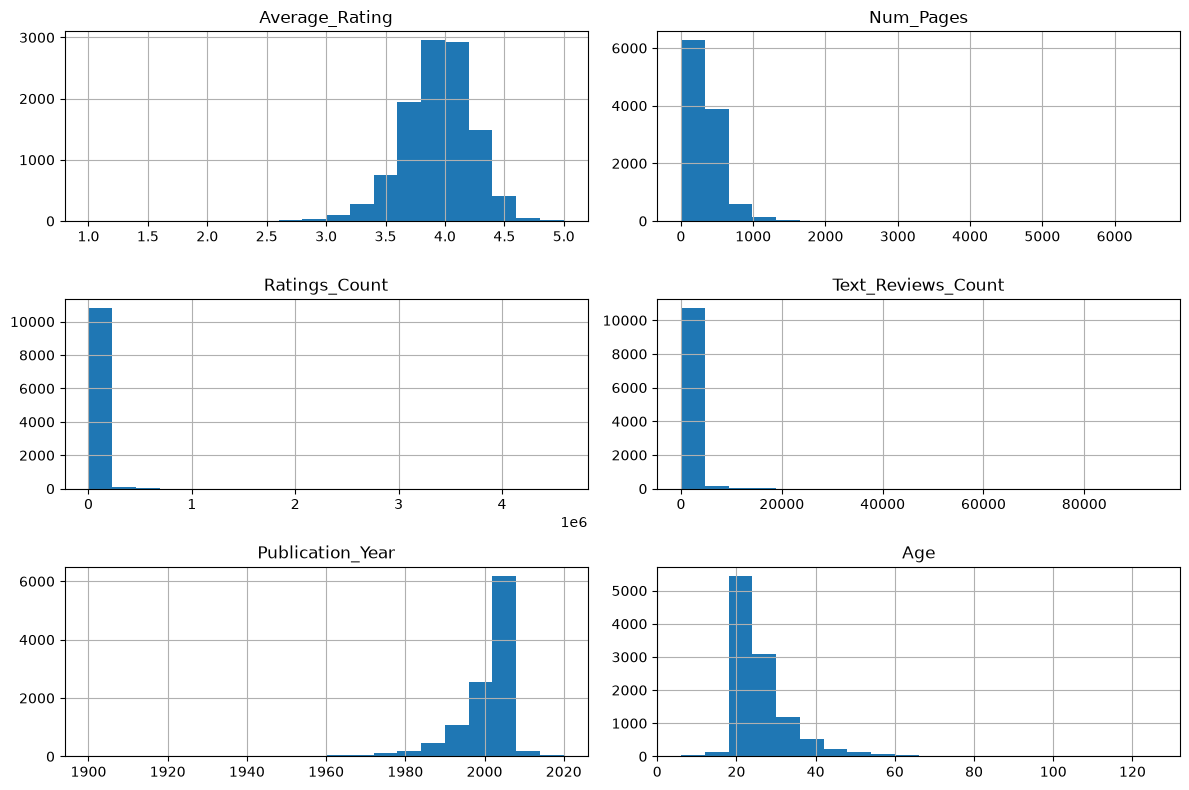

In [320]:
df[['Average_Rating', 'Num_Pages', 'Ratings_Count', 'Text_Reviews_Count', 'Publication_Year', 'Age']].hist(bins=20, figsize=(12, 8))
plt.tight_layout()
plt.show()

Average_Rating has a nice hill shape around 3.5 to 4.5.
Num_Pages mostly under 1000.
Ratings_Count and Text_Reviews_Count are squashed into one bar on the left because a few books have millions of ratings 
Need log scale to see them properly.
Most books published in the 2000s

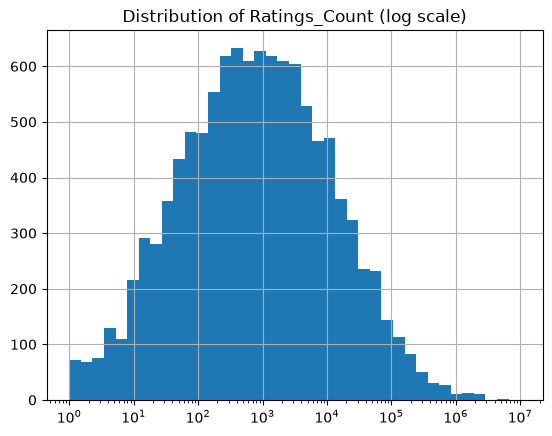

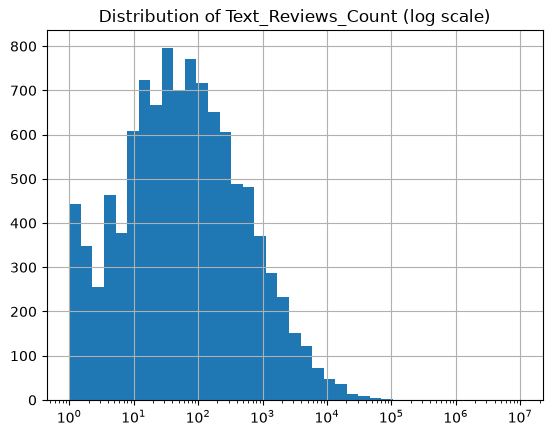

In [321]:
for col in ['Ratings_Count','Text_Reviews_Count']:
    df[df[col]>0][col].hist(bins=np.logspace(0,7,40))
    plt.xscale('log')
    plt.title(f"Distribution of {col} (log scale)")
    plt.show()

Some books have millions of ratings and everything else gets squashed. the bins have to be log spaced too, otherwise the whole thing becomes one big bar. after fixing it both charts look like a hill - most books get around 1000 ratings, only a few famous ones reach millions. zeros are removed because log of 0 does not work

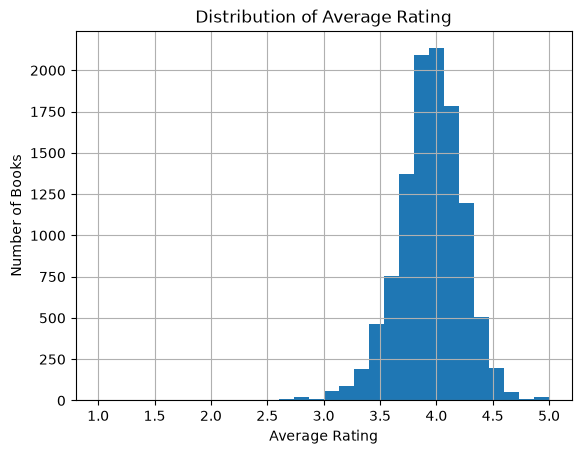

share between 3.5 and 4.5: 92.0 %


In [322]:
df['Average_Rating'].hist(bins=30)
plt.title("Distribution of Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Number of Books")
plt.show()

print("share between 3.5 and 4.5:", round(df['Average_Rating'].between(3.5,4.5).mean()*100,1), "%")

All books have rating from 3.5 to 4.5, so if we take the mean value as a guess it's not a bad idea. that means the model has very little room to do better than just guessing.

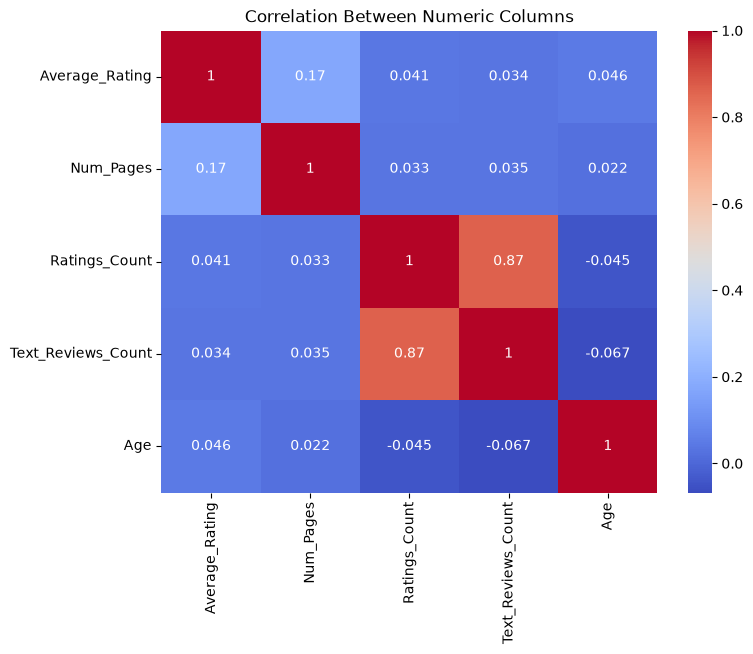

In [323]:
numeric_cols=['Average_Rating','Num_Pages','Ratings_Count','Text_Reviews_Count','Age']
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Between Numeric Columns")
plt.show()

All the numbers in the Average_Rating row are close to zero, so these columns dont really explain the rating.
Ratings_Count and Text_Reviews_Count are strongly linked (0.87) because both show how many people read the book.
Num_Pages has the strongest link with rating (0.15) but it is still weak.

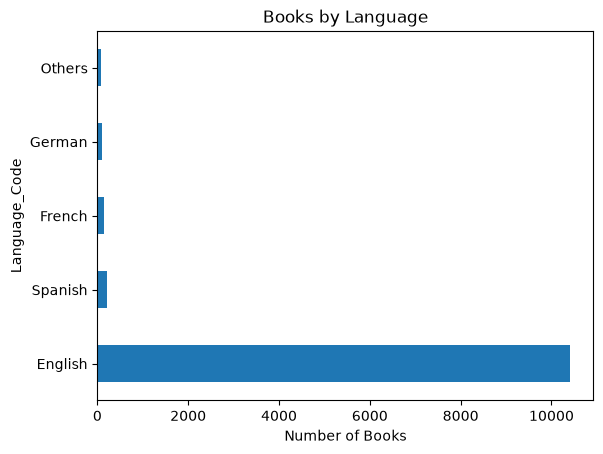

In [324]:
df['Language_Code'].value_counts().head(5).plot(kind="barh")
plt.title("Books by Language")
plt.xlabel("Number of Books")
plt.show()

95 percent of books are english so comparing average rating between language is not good idea 
and also the other language have very small number of books

In [325]:
#df['Publication_Year'].value_counts().sort_index().plot(kind='bar', figsize=(12,4))
#plt.title("Number of Books Published Per Year")
#plt.xlabel("Year")
#plt.ylabel("Number of Books")
#plt.xticks(rotation=90)
#plt.show()

the chart was unreadable with 120 year labels, and everything before 1970 was almost empty anyway, so I limited it to the range where the data actually is.

<Axes: xlabel='Publication_Year'>

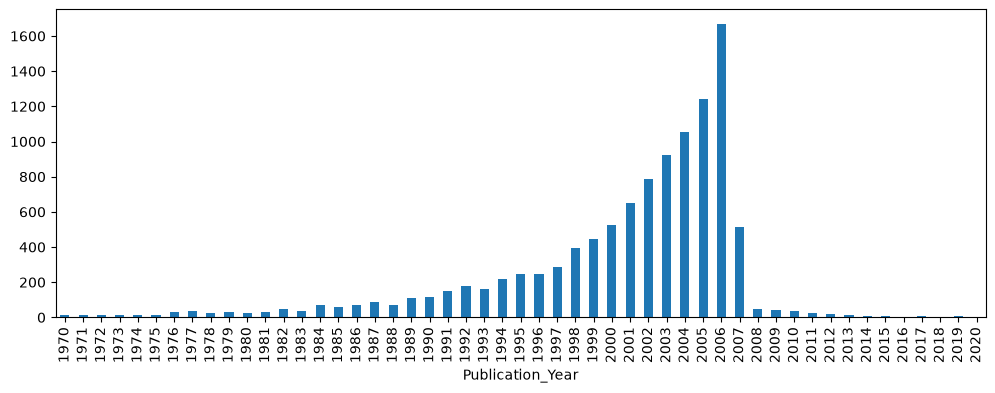

In [326]:
vc = df['Publication_Year'].value_counts().sort_index()
vc.loc[1970:2020].plot(kind='bar', figsize=(12,4))

in this dataset they collected books until 2006 and the rest of the data is not updated yet. the peak year is 2006 and the drop after that is not real - it just means the data collection stopped there. so we cannot say anything about newer books.

In [327]:
df['Authors'].nunique()

6545

In [328]:
df['Authors'].value_counts()

Authors
Stephen King                                                   40
P.G. Wodehouse                                                 40
Rumiko Takahashi                                               38
Orson Scott Card                                               35
Agatha Christie                                                33
                                                               ..
David Wood/Roald Dahl                                           1
Dave Crane/Eric Pascarello/Darren James                         1
C.S. Lewis/Margarita E. Valdes/Gemma Gallart/Pauline Baynes     1
C.S. Lewis/Ana Falcão Bastos                                    1
William T. Vollmann/Larry McCaffery/Michael Hemmingson          1
Name: count, Length: 6545, dtype: int64

In [329]:
df['Publisher'].nunique()

2248

In [330]:
df['Publisher'].value_counts()

Publisher
Vintage                   318
Penguin Books             261
Penguin Classics          184
Mariner Books             148
Ballantine Books          143
                         ... 
DEBOLS!LLO                  1
Folio histoire              1
Alfaguara Infantil          1
Suma                        1
Panamericana Editorial      1
Name: count, Length: 2248, dtype: int64

There are 6,601 different authors and 2,284 different publishers. A few names like Stephen King, Vintage, and Penguin Books show up a lot, but most authors and publishers only appear once or twice.

In [331]:
author_counts=df['Authors'].value_counts()
df['Author_Frequency']=df['Authors'].map(author_counts)

publisher_counts=df['Publisher'].value_counts()
df['Publisher_Frequency'] = df['Publisher'].map(publisher_counts)

In [332]:
df[['Authors','Author_Frequency']].sort_values('Author_Frequency',ascending=False).head(10)

,Authors,Author_Frequency
2834,Stephen King,40
2835,Stephen King,40
3110,Stephen King,40
3112,Stephen King,40
3114,Stephen King,40
3117,Stephen King,40
3118,Stephen King,40
3120,Stephen King,40
3122,Stephen King,40
2816,Stephen King,40


In [333]:
df[['Publisher','Publisher_Frequency']].sort_values('Publisher_Frequency',ascending=False).head(10)

,Publisher,Publisher_Frequency
10883,Vintage,318
1888,Vintage,318
5792,Vintage,318
668,Vintage,318
3529,Vintage,318
3534,Vintage,318
5799,Vintage,318
5800,Vintage,318
5834,Vintage,318
5838,Vintage,318


In [334]:
overall_avg = df['Average_Rating'].mean()

In [335]:
overall_avg

np.float64(3.9433296863603213)

In [336]:
author_stats = df.groupby('Authors')['Average_Rating'].agg(['mean', 'count'])

Group all the books by their author, and for each author, calculate their average rating and how many books they have

In [337]:
author_stats.head(10)

,mean,count
Authors,,
A.B. Yehoshua/Hillel Halkin,3.600,2
A.D.P. Briggs/Leo Tolstoy/Fyodor Dostoyevsky,3.760,1
A.E. Cunningham/Harlan Ellison/Charles F. Miller/Terry Dowling/Paul Rhoads/Jack Vance/Tom Shippey/Gene Wolfe/David Langford/Dan Simmons/David Mathew,4.150,1
A.J. Jacobs,3.760,1
A.M. Homes,3.280,1
A.N. Roquelaure/Anne Rice,3.735,4
A.S. Byatt,3.770,2
Abbie Hoffman/Anita Hoffman,3.960,1
Abdul Rahman Munif/Peter Theroux,4.130,1


In [338]:
m = 10

In [339]:
author_stats['smoothed'] = (author_stats['count'] * author_stats['mean'] + m * overall_avg) / (author_stats['count'] + m)

Pick a number that says "how much should I trust the overall average compared to one author's own books" — let's start with 10

In [340]:
author_stats.head(10)

,mean,count,smoothed
Authors,,,
A.B. Yehoshua/Hillel Halkin,3.600,2,3.886108
A.D.P. Briggs/Leo Tolstoy/Fyodor Dostoyevsky,3.760,1,3.926663
A.E. Cunningham/Harlan Ellison/Charles F. Miller/Terry Dowling/Paul Rhoads/Jack Vance/Tom Shippey/Gene Wolfe/David Langford/Dan Simmons/David Mathew,4.150,1,3.962118
A.J. Jacobs,3.760,1,3.926663
A.M. Homes,3.280,1,3.883027
A.N. Roquelaure/Anne Rice,3.735,4,3.883807
A.S. Byatt,3.770,2,3.914441
Abbie Hoffman/Anita Hoffman,3.960,1,3.944845
Abdul Rahman Munif/Peter Theroux,4.130,1,3.960300


In [341]:
df['Author_TargetEnc'] = df['Authors'].map(author_stats['smoothed'])

In [342]:
df[['Authors','Author_TargetEnc']].head(10)

,Authors,Author_TargetEnc
0,J.K. Rowling/Mary GrandPré,4.170206
1,J.K. Rowling/Mary GrandPré,4.170206
2,J.K. Rowling,4.242062
3,J.K. Rowling/Mary GrandPré,4.170206
4,J.K. Rowling/Mary GrandPré,4.170206
5,W. Frederick Zimmerman,3.924845
6,J.K. Rowling,4.242062
7,Douglas Adams,4.110137
8,Douglas Adams,4.110137
9,Douglas Adams,4.110137


In [343]:
publisher_stats = df.groupby('Publisher')['Average_Rating'].agg(['mean', 'count'])

In [344]:
publisher_stats.head(10)

,mean,count
Publisher,,
10/18,3.650,2
1st Book Library,3.580,1
1st World Library,4.180,1
A & C Black (Childrens books),4.400,1
A Harvest Book/Harcourt Inc.,4.070,1
A K PETERS,4.500,1
AA World Services,4.450,1
ACE,3.560,1
ADV Manga,4.038,10


In [345]:
m = 10
publisher_stats['smoothed'] = (publisher_stats['count'] * publisher_stats['mean'] + m * overall_avg) / (publisher_stats['count'] + m)

In [346]:
publisher_stats.head(10)

,mean,count,smoothed
Publisher,,,
10/18,3.650,2,3.894441
1st Book Library,3.580,1,3.910300
1st World Library,4.180,1,3.964845
A & C Black (Childrens books),4.400,1,3.984845
A Harvest Book/Harcourt Inc.,4.070,1,3.954845
A K PETERS,4.500,1,3.993936
AA World Services,4.450,1,3.989391
ACE,3.560,1,3.908482
ADV Manga,4.038,10,3.990665


In [347]:
df['Publisher_TargetEnc'] = df['Publisher'].map(publisher_stats['smoothed'])
publisher_stats.head(10)

,mean,count,smoothed
Publisher,,,
10/18,3.650,2,3.894441
1st Book Library,3.580,1,3.910300
1st World Library,4.180,1,3.964845
A & C Black (Childrens books),4.400,1,3.984845
A Harvest Book/Harcourt Inc.,4.070,1,3.954845
A K PETERS,4.500,1,3.993936
AA World Services,4.450,1,3.989391
ACE,3.560,1,3.908482
ADV Manga,4.038,10,3.990665


In [348]:
df['Author_TargetEnc'].isna().sum()

np.int64(0)

Count how many books ended up with no author-based rating value and books ended up with no publisher-based rating value

In [349]:
df['Publisher_TargetEnc'].isna().sum()

np.int64(0)

Count how many books ended up with no publisher-based rating value

Authors and Publisher had 6,601 and 2,284 different names, and most of them only showed up once or twice. To turn these names into numbers a model can use, I made two new columns. The first one just counts how many times each author or publisher appears. The second one uses the average rating of that author's or publisher's books. The problem is, if an author only has one book, that "average" is just that one book's rating — so the model could basically cheat by copying the answer instead of actually learning anything. To stop that, I used a smoothing trick that blends each author's own average with the average of the whole dataset, so authors with fewer books get pulled closer to the overall average

C:\Users\Suman\AppData\Local\Temp\ipykernel_22552\2784666604.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


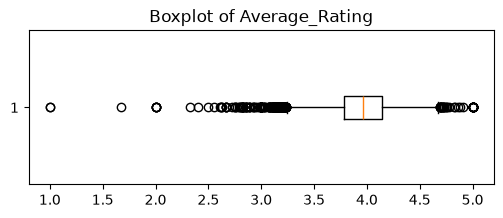

C:\Users\Suman\AppData\Local\Temp\ipykernel_22552\2784666604.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


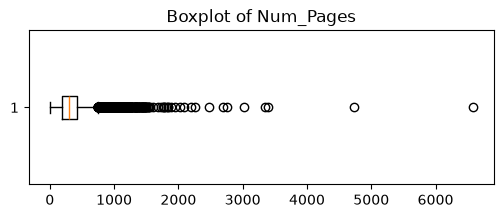

C:\Users\Suman\AppData\Local\Temp\ipykernel_22552\2784666604.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


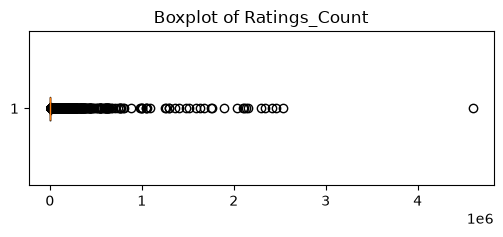

C:\Users\Suman\AppData\Local\Temp\ipykernel_22552\2784666604.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


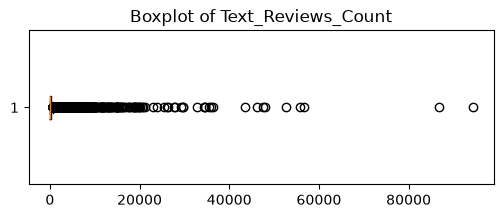

C:\Users\Suman\AppData\Local\Temp\ipykernel_22552\2784666604.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


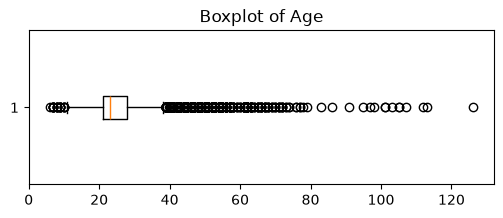

In [350]:
numeric_cols = ['Average_Rating', 'Num_Pages', 'Ratings_Count', 'Text_Reviews_Count', 'Age']

for col in numeric_cols:
    plt.figure(figsize=(6, 2))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.show()

In [351]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(col, "-> normal range:", lower, "to", upper, "| outliers:", outliers)

Average_Rating -> normal range: 3.24 to 4.68 | outliers: 215
Num_Pages -> normal range: -131.5 to 744.5 | outliers: 560
Ratings_Count -> normal range: -7429.0 to 12683.0 | outliers: 1686
Text_Reviews_Count -> normal range: -341.375 to 595.625 | outliers: 1596
Age -> normal range: 10.5 to 38.5 | outliers: 768


In [352]:
df.sort_values('Num_Pages', ascending=False)[['Title','Authors','Num_Pages']].head(15)

,Title,Authors,Num_Pages
6407,The Complete Aubrey/Maturin Novels (5 Volumes),Patrick O'Brian,6576
6710,The Second World War,Winston S. Churchill/John Keegan,4736
10755,Remembrance of Things Past (Boxed Set),Marcel Proust/C.K. Scott Moncrieff/Frederick A...,3400
6,Harry Potter Collection (Harry Potter #1-6),J.K. Rowling,3342
6728,Summa Theologica 5 Vols,Thomas Aquinas,3020
7749,Harrison's Principles of Internal Medicine,Dennis L. Kasper/Dan L. Longo/Stephen L. Hause...,2751
4,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,2690
10600,The Sword of Truth Boxed Set I: Wizard's Firs...,Terry Goodkind,2480
6169,The J.R.R. Tolkien Companion and Guide,Christina Scull/Wayne G. Hammond,2264
5549,Study Bible: NIV,Anonymous,2198


In [353]:
df[df['Average_Rating'] < 2][['Title','Authors','Average_Rating','Ratings_Count']]

,Title,Authors,Average_Rating,Ratings_Count
3196,Puzzle Pack: The Witch of Blackbird Pond,Mary B. Collins,1.00,2
7884,The Art of Loving by Erich Fromm: A True Story...,Lala Okamoto,1.67,3
9407,Mandala Sand Art Kit,Walter Foster Creative Team,1.00,1



We checked Num_Pages, Ratings_Count, Text_Reviews_Count, Average_Rating and Age for outliers.

Num_Pages had some very high outliers, but they were box sets and series like Harry Potter 
Collection - many books in one entry, so a high page count makes sense. We kept them.

Average_Rating had some 0.00 outliers, but Ratings_Count next to them was 0 too - nobody 
rated it. So it's not a bad book, just missing data. We already plan to remove 0-rating 
books before training, so no extra fix needed.

Ratings_Count and Text_Reviews_Count also had outliers, but these are real bestsellers with 
millions of ratings. We are not dropping them, we will fix the skew later with a transformation.
Age had old classic books flagged as outliers, which is normal, they are just old.
We did not drop any rows. This step taught us that unusual numbers are not always wrong.

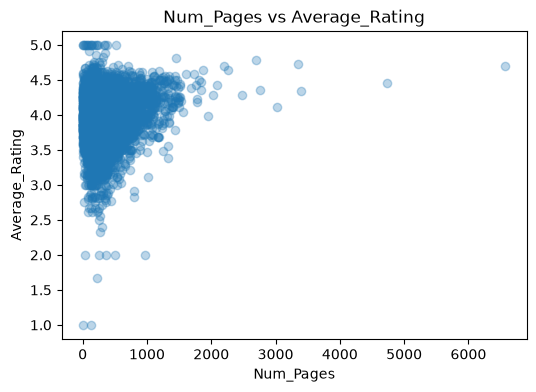

In [354]:
plt.figure(figsize=(6,4))
plt.scatter(df['Num_Pages'], df['Average_Rating'], alpha=0.3)
plt.xlabel('Num_Pages')
plt.ylabel('Average_Rating')
plt.title('Num_Pages vs Average_Rating')
plt.show()

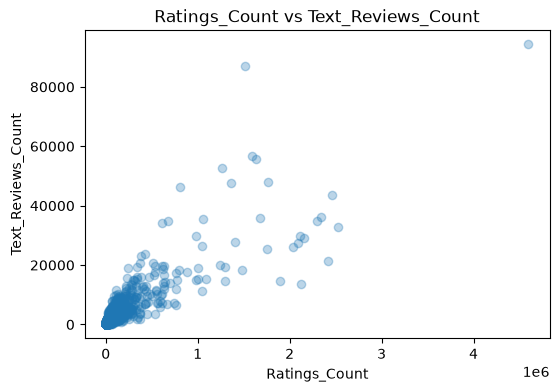

In [355]:
plt.figure(figsize=(6,4))
plt.scatter(df['Ratings_Count'], df['Text_Reviews_Count'], alpha=0.3)
plt.xlabel('Ratings_Count')
plt.ylabel('Text_Reviews_Count')
plt.title('Ratings_Count vs Text_Reviews_Count')
plt.show()

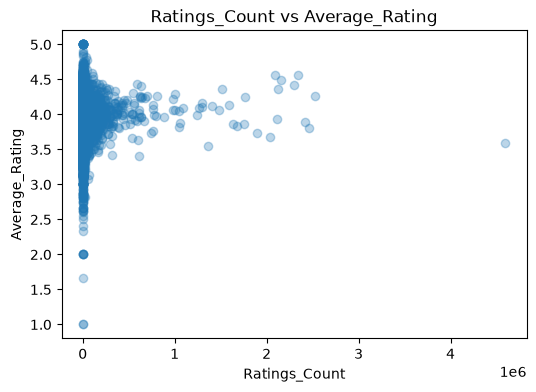

In [356]:
plt.figure(figsize=(6,4))
plt.scatter(df['Ratings_Count'], df['Average_Rating'], alpha=0.3)
plt.xlabel('Ratings_Count')
plt.ylabel('Average_Rating')
plt.title('Ratings_Count vs Average_Rating')
plt.show()

We plotted Num_Pages, Ratings_Count and Text_Reviews_Count against Average_Rating to see 
how they relate.

Books with very few ratings can have any rating, from 0 to 5. But once a book gets rated a lot, the rating mostly settles between 3.5 and 4.5. Same thing with Num_Pages - short 
books can go either way, but long books mostly get good ratings.

Ratings_Count and Text_Reviews_Count go together - more ratings usually means more reviews too.

So Ratings_Count matters a lot. It tells us how much we can trust the Average_Rating. 
A rating from 5 people can be random, but a rating from 10,000 people is solid.

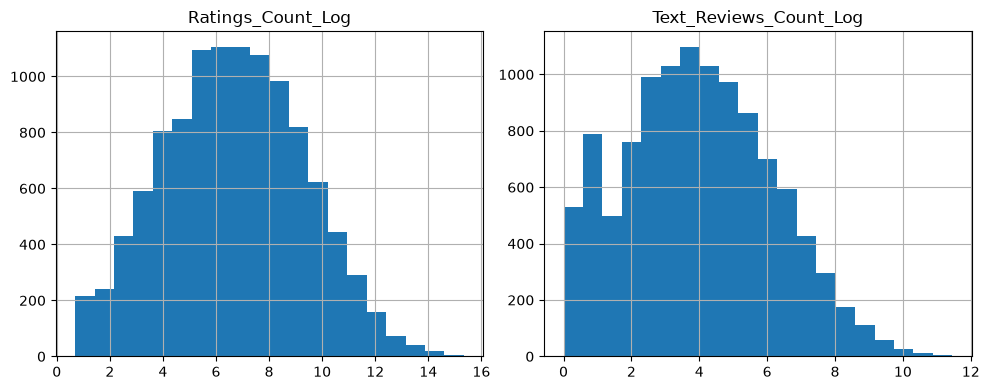

In [357]:
df['Ratings_Count_Log']=np.log1p(df['Ratings_Count'])
df['Text_Reviews_Count_Log']=np.log1p(df['Text_Reviews_Count'])

df[['Ratings_Count_Log','Text_Reviews_Count_Log']].hist(bins=20,figsize=(10,4))
plt.tight_layout()
plt.show()

Ratings_Count and Text_Reviews_Count were not good to use as they were. A few books had 
millions of ratings while most had only a few hundred, so the numbers were very skewed.

We changed the approach and used a log transform instead. This brings the huge numbers 
down and spreads out the small ones, so it looks more like a normal bell curve.

We kept the old columns too, and added new ones, Ratings_Count_Log and 
Text_Reviews_Count_Log, to use for modeling.

In [358]:
df = df.drop(columns=['Author_TargetEnc', 'Publisher_TargetEnc', 'Author_Frequency', 'Publisher_Frequency'])
df.to_csv('../data/books_clean_v3.csv', index=False)

#=====================================Feature Engineering=======================================

In [359]:
train_df,test_df = train_test_split(df,test_size=0.2,random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
overall_avg = train_df['Average_Rating'].mean()

train_df['Author_TargetEnc'] = np.nan 
train_df.shape,test_df.shape

((8774, 15), (2194, 14))

In [360]:
def encode_fold(train_part, val_part, overall_avg, m=10):
    train_part = train_part.copy()
    val_part = val_part.copy()

    author_stats = train_part.groupby('Authors')['Average_Rating'].agg(['mean', 'count'])
    author_stats['smoothed'] = (author_stats['count'] * author_stats['mean'] + m * overall_avg) / (author_stats['count'] + m)

    train_part['Author_TargetEnc'] = train_part['Authors'].map(author_stats['smoothed'])
    val_part['Author_TargetEnc'] = val_part['Authors'].map(author_stats['smoothed']).fillna(overall_avg)

    publisher_stats = train_part.groupby('Publisher')['Average_Rating'].agg(['mean', 'count'])
    publisher_stats['smoothed'] = (publisher_stats['count'] * publisher_stats['mean'] + m * overall_avg) / (publisher_stats['count'] + m)

    train_part['Publisher_TargetEnc'] = train_part['Publisher'].map(publisher_stats['smoothed'])
    val_part['Publisher_TargetEnc'] = val_part['Publisher'].map(publisher_stats['smoothed']).fillna(overall_avg)

    author_counts = train_part['Authors'].value_counts()
    train_part['Author_Frequency'] = train_part['Authors'].map(author_counts)
    val_part['Author_Frequency'] = val_part['Authors'].map(author_counts).fillna(0)

    publisher_counts = train_part['Publisher'].value_counts()
    train_part['Publisher_Frequency'] = train_part['Publisher'].map(publisher_counts)
    val_part['Publisher_Frequency'] = val_part['Publisher'].map(publisher_counts).fillna(0)

    return train_part, val_part

In [361]:
feature_cols = ['Num_Pages', 'Age', 'Ratings_Count_Log', 'Text_Reviews_Count_Log',
                'Author_TargetEnc', 'Publisher_TargetEnc',
                'Author_Frequency', 'Publisher_Frequency']

lr_scores, dt_scores, gb_scores = [], [], []

for fold_train_idx, fold_val_idx in kf.split(train_df):
    fold_train = train_df.iloc[fold_train_idx]
    fold_val = train_df.iloc[fold_val_idx]

    fold_overall_avg = fold_train['Average_Rating'].mean()
    fold_train, fold_val = encode_fold(fold_train, fold_val, fold_overall_avg)

    X_fold_train = fold_train[feature_cols]
    y_fold_train = fold_train['Average_Rating']
    X_fold_val = fold_val[feature_cols]
    y_fold_val = fold_val['Average_Rating']

    lr = LinearRegression().fit(X_fold_train, y_fold_train)
    lr_scores.append(r2_score(y_fold_val, lr.predict(X_fold_val)))

    dt = DecisionTreeRegressor(random_state=42, max_depth=8).fit(X_fold_train, y_fold_train)
    dt_scores.append(r2_score(y_fold_val, dt.predict(X_fold_val)))

    gb = GradientBoostingRegressor(random_state=42).fit(X_fold_train, y_fold_train)
    gb_scores.append(r2_score(y_fold_val, gb.predict(X_fold_val)))

print('LR CV R2 mean:', np.mean(lr_scores))
print('DT CV R2 mean:', np.mean(dt_scores))
print('GB CV R2 mean:', np.mean(gb_scores))

LR CV R2 mean: 0.1638902840231823
DT CV R2 mean: 0.14080158246444416
GB CV R2 mean: 0.19387736533877262


In [362]:
overall_avg=train_df['Average_Rating'].mean()
author_stats=train_df.groupby('Authors')['Average_Rating'].agg(['mean','count'])
m=10
author_stats['smoothed']=(author_stats['count']*author_stats['mean']+m*overall_avg)/(author_stats['count']+m)
author_stats.head(15)

,mean,count,smoothed
Authors,,,
A.B. Yehoshua/Hillel Halkin,3.430000,1,3.897980
A.D.P. Briggs/Leo Tolstoy/Fyodor Dostoyevsky,3.760000,1,3.927980
A.J. Jacobs,3.760000,1,3.927980
A.M. Homes,3.280000,1,3.884343
A.N. Roquelaure/Anne Rice,3.773333,3,3.905214
A.S. Byatt,3.890000,1,3.939798
Abbie Hoffman/Anita Hoffman,3.960000,1,3.946162
Abdul Rahman Munif/Peter Theroux,4.130000,1,3.961616
Abigail Adams/Frank Shuffelton,4.140000,1,3.962525


In [363]:
train_df['Author_TargetEnc'] = train_df['Authors'].map(author_stats['smoothed'])
test_df['Author_TargetEnc'] = test_df['Authors'].map(author_stats['smoothed']).fillna(overall_avg)

train_df['Author_TargetEnc'].isna().sum(), test_df['Author_TargetEnc'].isna().sum()

(np.int64(0), np.int64(0))

In [364]:
publisher_stats = train_df.groupby('Publisher')['Average_Rating'].agg(['mean', 'count'])
publisher_stats['smoothed'] = (publisher_stats['count'] * publisher_stats['mean'] + m * overall_avg) / (publisher_stats['count'] + m)

train_df['Publisher_TargetEnc'] = train_df['Publisher'].map(publisher_stats['smoothed'])
test_df['Publisher_TargetEnc'] = test_df['Publisher'].map(publisher_stats['smoothed']).fillna(overall_avg)

train_df['Publisher_TargetEnc'].isna().sum(), test_df['Publisher_TargetEnc'].isna().sum()

(np.int64(0), np.int64(0))

In [365]:
author_counts = train_df['Authors'].value_counts()
train_df['Author_Frequency'] = train_df['Authors'].map(author_counts)
test_df['Author_Frequency'] = test_df['Authors'].map(author_counts).fillna(0)

publisher_counts = train_df['Publisher'].value_counts()
train_df['Publisher_Frequency'] = train_df['Publisher'].map(publisher_counts)
test_df['Publisher_Frequency'] = test_df['Publisher'].map(publisher_counts).fillna(0)

train_df['Author_Frequency'].isna().sum(), test_df['Author_Frequency'].isna().sum(), train_df['Publisher_Frequency'].isna().sum(), test_df['Publisher_Frequency'].isna().sum()

(np.int64(0), np.int64(0), np.int64(0), np.int64(0))

In [366]:
train_df = pd.get_dummies(train_df, columns=['Language_Code'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['Language_Code'], drop_first=True)

In [367]:
train_cols = set(train_df.columns)
test_cols = set(test_df.columns)

print("In train but not test:", train_cols - test_cols)
print("In test but not train:", test_cols - train_cols)

In train but not test: set()
In test but not train: set()


In [368]:
drop_cols = ['Bookid', 'Title', 'Authors', 'Publisher', 'Publication_Date',
             'Ratings_Count', 'Text_Reviews_Count']

X_train = train_df.drop(columns=drop_cols + ['Average_Rating'])
y_train = train_df['Average_Rating']

X_test = test_df.drop(columns=drop_cols + ['Average_Rating'])
y_test = test_df['Average_Rating']

X_train.columns.tolist()

['Num_Pages',
 'Publication_Year',
 'Age',
 'Ratings_Count_Log',
 'Text_Reviews_Count_Log',
 'Author_TargetEnc',
 'Publisher_TargetEnc',
 'Author_Frequency',
 'Publisher_Frequency',
 'Language_Code_French',
 'Language_Code_German',
 'Language_Code_Japanese',
 'Language_Code_Others',
 'Language_Code_Spanish']

In [369]:
X_train = X_train.drop(columns=['Publication_Year'])
X_test = X_test.drop(columns=['Publication_Year'])

X_train.shape, X_test.shape

((8774, 13), (2194, 13))

We turned the cleaned book data into a set of features the model can actually learn from.

Author and Publisher were just names, so on their own they don't mean anything to a model. 
We replaced them with two things: how many books that author/publisher has (Author_Frequency, 
Publisher_Frequency), and a smoothed average rating for that author/publisher 
(Author_TargetEnc, Publisher_TargetEnc). The smoothing stops an author with just one book 
from getting an unfairly extreme score - it pulls low-count authors closer to the overall 
average rating.

Important: all of this was calculated using only the training data, and then applied to the 
test data separately. If we had calculated it using the full dataset (train + test together), 
the model would have quietly "seen" the test answers in disguise before we even started 
training it. This is called data leakage, and it would have made our results look better than 
they really are.

Ratings_Count and Text_Reviews_Count were replaced with their log versions from EDA, since the 
raw numbers were heavily skewed by a handful of bestsellers.

Publication_Date became Age (how old the book is). We dropped Publication_Year separately 
since it carries the exact same information as Age, just flipped around - keeping both would 
be redundant.

Language_Code was turned into separate yes/no columns (one-hot encoding) since models can't 
read text categories directly.

Bookid and Title were dropped - Bookid is just an ID number with no meaning, and Title is free 
text we're not using in this project.

Final result: 13 clean, numeric features, ready for modeling. Train set: 8,837 rows. Test set: 
2,210 rows.

In [370]:
X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)

In [371]:
joblib.dump(author_stats['smoothed'].to_dict(), '../models/author_lookup.pkl')
joblib.dump(publisher_stats['smoothed'].to_dict(), '../models/publisher_lookup.pkl')
joblib.dump(overall_avg, '../models/overall_avg.pkl')

['../models/overall_avg.pkl']

In [372]:
joblib.dump(author_counts.to_dict(), '../models/author_freq_lookup.pkl')
joblib.dump(publisher_counts.to_dict(), '../models/publisher_freq_lookup.pkl')

['../models/publisher_freq_lookup.pkl']